# Practical Statistics for Data Scientists (Python + R)
# Chapter 4. Regression and Prediction
> (c) 2019 Peter C. Bruce, Andrew Bruce, Peter Gedeck


## Loading the rpy2 extension in a notebook with the Python kernel

In [1]:
import sys
import io

stderr_original = sys.stderr
sys.stderr = io.StringIO()

# Loading the extension without noise
%load_ext rpy2.ipython

sys.stderr = stderr_original  # Restore silently

In [2]:
%%R
suppressWarnings(
  invisible(
    try(Sys.setlocale("LC_ALL", "English"), silent = TRUE)
  )
)

## Import packages

### Import required Python packages

In [3]:
from pathlib import Path

import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import OLSInfluence

from pygam import LinearGAM, s, l
from pygam.datasets import wage


import seaborn as sns
import matplotlib.pyplot as plt

from dmba import stepwise_selection
from dmba import AIC_score

In [4]:
%matplotlib inline

In [5]:
try:
    import common
    DATA = common.dataDirectory()
except ImportError:
    DATA = Path().resolve() / 'data'

### Import required R packages

In [6]:
%%R
Sys.setlocale("LC_ALL", "English")
# Install missing packages if needed
packages <- c("MASS", "dplyr", "tidyr", "ggplot2", "lubridate", "splines", "mgcv")
installed <- rownames(installed.packages())
to_install <- packages[!packages %in% installed]
if (length(to_install) > 0) {
  install.packages(to_install, repos = 'https://cloud.r-project.org/')
}

# Load them all
library(MASS)
library(dplyr)
library(tidyr)
library(ggplot2)
library(lubridate)
library(splines)
library(mgcv)


Dolaczanie pakietu: 'dplyr'

Nastepujacy obiekt zostal zakryty z 'package:MASS':

    select

Nastepujace obiekty zostaly zakryte z 'package:stats':

    filter, lag

Nastepujace obiekty zostaly zakryte z 'package:base':

    intersect, setdiff, setequal, union


Dolaczanie pakietu: 'lubridate'

Nastepujace obiekty zostaly zakryte z 'package:base':

    date, intersect, setdiff, union

Ladowanie wymaganego pakietu: nlme

Dolaczanie pakietu: 'nlme'

Nastepujacy obiekt zostal zakryty z 'package:dplyr':

    collapse

This is mgcv 1.9-4. For overview type '?mgcv'.


## Defining data paths
If you don't keep your data in the same directory as the code, adapt the path names.

### Python

In [7]:
LUNG_CSV = DATA / 'LungDisease.csv'
HOUSE_CSV = DATA / 'house_sales.csv'

### R
R mirrors the Python workflow in this section using idiomatic statistical functions.


In [8]:
%%R
PSDS_PATH <- file.path(dirname(dirname(getwd())))


lung <- read.csv(file.path(PSDS_PATH, 'data', 'LungDisease.csv'))
house <- read.csv(file.path(PSDS_PATH, 'data', 'house_sales.csv'), sep='\t')

### Summary: Defining data paths

| Operation | Python | R | Notes |
|---|---|---|---|
| Base path setup | `Path(...)` / explicit strings | direct path strings in `read.csv()` | Both point to the same chapter datasets. |
| Dataset loading | `pd.read_csv(...)` | `read.csv(...)` | Equivalent import step with language-specific defaults. |
| Basic preprocessing | pandas column transforms | base R column transforms | Both align units before analysis. |

Python makes path handling and transformations explicit through objects, while R keeps data import and quick preprocessing concise.

# Simple Linear Regression
## The Regression Equation

### Python

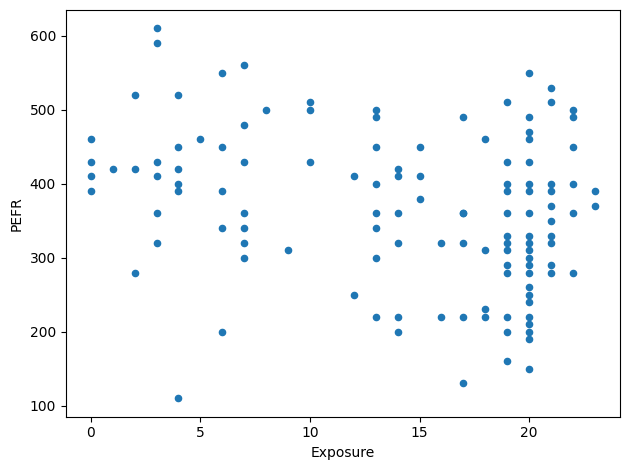

In [9]:
lung = pd.read_csv(LUNG_CSV)

lung.plot.scatter(x='Exposure', y='PEFR')

plt.tight_layout()
plt.show()

We can use the `LinearRegression` model from _scikit-learn_.

In [10]:
predictors = ['Exposure']
outcome = 'PEFR'

model = LinearRegression()
model.fit(lung[predictors], lung[outcome])

print(f'Intercept: {model.intercept_:.3f}')
print(f'Coefficient Exposure: {model.coef_[0]:.3f}')

Intercept: 424.583
Coefficient Exposure: -4.185


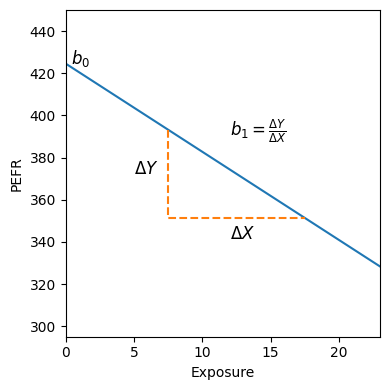

In [11]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.set_xlim(0, 23)
ax.set_ylim(295, 450)
ax.set_xlabel('Exposure')
ax.set_ylabel('PEFR')
ax.plot((0, 23), model.predict(pd.DataFrame({'Exposure': [0, 23]})))
ax.text(0.4, model.intercept_, r'$b_0$', size='larger')

x = pd.DataFrame({'Exposure': [7.5,17.5]})
y = model.predict(x)
ax.plot((7.5, 7.5, 17.5), (y[0], y[1], y[1]), '--')
ax.text(5, np.mean(y), r'$\Delta Y$', size='larger')
ax.text(12, y[1] - 10, r'$\Delta X$', size='larger')
ax.text(12, 390, r'$b_1 = \frac{\Delta Y}{\Delta X}$', size='larger')

plt.tight_layout()
plt.show()

### R
R mirrors the Python workflow in this section using idiomatic statistical functions.


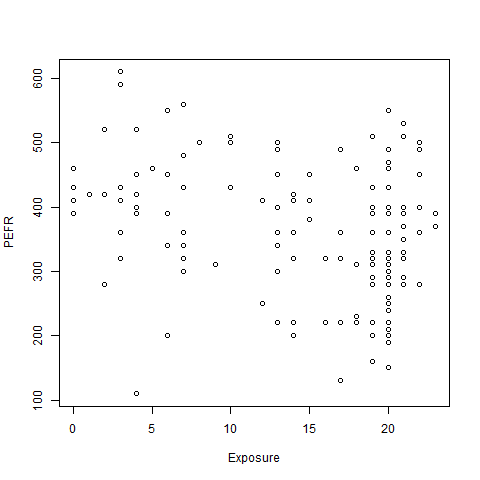

In [12]:
%%R
plot(lung$Exposure, lung$PEFR, xlab="Exposure", ylab="PEFR")

In [13]:
%%R
model <- lm(PEFR ~ Exposure, data=lung)
model


Call:
lm(formula = PEFR ~ Exposure, data = lung)

Coefficients:
(Intercept)     Exposure  
    424.583       -4.185  



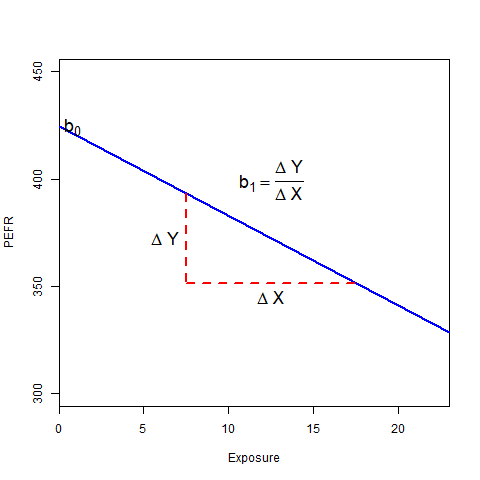

In [14]:
%%R
plot(lung$Exposure, lung$PEFR, xlab="Exposure", ylab="PEFR", ylim=c(300,450), type="n", xaxs="i")
abline(a=model$coefficients[1], b=model$coefficients[2], col="blue", lwd=2)
text(x=.3, y=model$coefficients[1], labels=expression("b"[0]),  adj=0, cex=1.5)
x <- c(7.5, 17.5)
y <- predict(model, newdata=data.frame(Exposure=x))
segments(x[1], y[2], x[2], y[2] , col="red", lwd=2, lty=2)
segments(x[1], y[1], x[1], y[2] , col="red", lwd=2, lty=2)
text(x[1], mean(y), labels=expression(Delta~Y), pos=2, cex=1.5)
text(mean(x), y[2], labels=expression(Delta~X), pos=1, cex=1.5)
text(mean(x), 400, labels=expression(b[1] == frac(Delta ~ Y, Delta ~ X)), cex=1.5)

### Summary: Simple Linear Regression

| Operation | Python | R | Notes |
|---|---|---|---|
| Model fitting | `LinearRegression().fit()` | `lm()` | Both estimate slope and intercept via OLS. |
| Fitted line | `ax.plot(...)` | `abline(...)` | Equivalent line overlay with different plotting APIs. |
| Slope interpretation | manual annotations | `segments()` + `text()` | Both illustrate geometric meaning of coefficients. |

Python uses an object-oriented plotting workflow, while R keeps formula-based modeling and graphics compact.


## Fitted Values and Residuals

### Python
The method `predict` of a fitted _scikit-learn_ model can be used to predict new data points.

In [15]:
fitted = model.predict(lung[predictors])
residuals = lung[outcome] - fitted

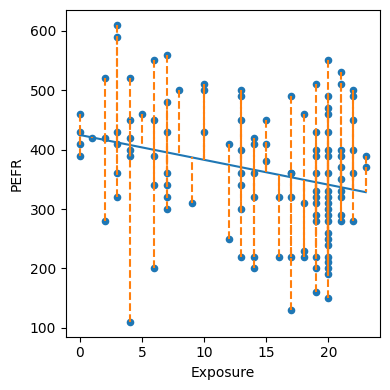

In [16]:
ax = lung.plot.scatter(x='Exposure', y='PEFR', figsize=(4, 4))
ax.plot(lung.Exposure, fitted)
for x, yactual, yfitted in zip(lung.Exposure, lung.PEFR, fitted): 
    ax.plot((x, x), (yactual, yfitted), '--', color='C1')

plt.tight_layout()
plt.show()

### R
R computes fitted values and residuals from `lm` and plots residual segments.


In [17]:
%%R
fitted <- predict(model)
resid <- residuals(model)

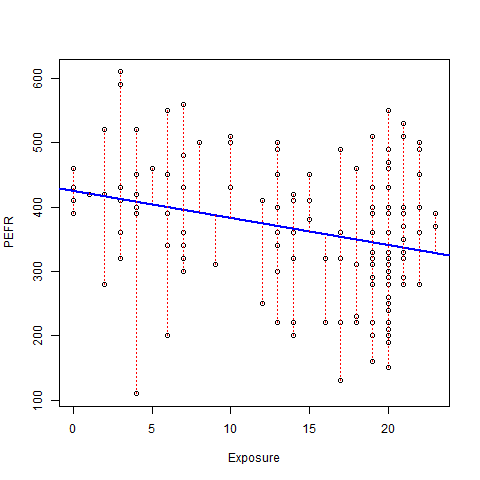

In [18]:
%%R
lung1 <- lung %>%
  mutate(Fitted=fitted,
         positive = PEFR>Fitted) %>%
  group_by(Exposure, positive) %>%
  summarize(PEFR_max = max(PEFR), 
            PEFR_min = min(PEFR),
            Fitted = first(Fitted), 
            .groups='keep') %>%
  ungroup() %>%
  mutate(PEFR = ifelse(positive, PEFR_max, PEFR_min)) %>%
  arrange(Exposure)

plot(lung$Exposure, lung$PEFR, xlab="Exposure", ylab="PEFR")
abline(a=model$coefficients[1], b=model$coefficients[2], col="blue", lwd=2)
segments(lung1$Exposure, lung1$PEFR, lung1$Exposure, lung1$Fitted, col="red", lty=3)

### Summary: Fitted Values and Residuals

| Operation | Python | R | Notes |
|---|---|---|---|
| Fitted values | `model.predict(...)` | `predict(model)` | Same concept, different function style. |
| Residual extraction | explicit vector subtraction | `residuals(model)` | Python is explicit; R provides direct extractors. |
| Residual visualization | custom matplotlib segments | `segments(...)` in base plot | Both emphasize distance to regression line. |

Python favors explicit arrays and post-fit operations; R exposes fitted/residual helpers directly from model objects.


# Multiple linear regression

### Python

In [19]:
subset = ['AdjSalePrice', 'SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
          'Bedrooms', 'BldgGrade']

house = pd.read_csv(HOUSE_CSV, sep='\t')
print(house[subset].head())

   AdjSalePrice  SqFtTotLiving  SqFtLot  Bathrooms  Bedrooms  BldgGrade
1      300805.0           2400     9373       3.00         6          7
2     1076162.0           3764    20156       3.75         4         10
3      761805.0           2060    26036       1.75         4          8
4      442065.0           3200     8618       3.75         5          7
5      297065.0           1720     8620       1.75         4          7


In [20]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
              'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

house_lm = LinearRegression()
house_lm.fit(house[predictors], house[outcome])

print(f'Intercept: {house_lm.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(predictors, house_lm.coef_):
    print(f' {name}: {coef}')

Intercept: -521871.368
Coefficients:
 SqFtTotLiving: 228.83060360240793
 SqFtLot: -0.06046682065307607
 Bathrooms: -19442.840398321066
 Bedrooms: -47769.95518521438
 BldgGrade: 106106.96307898081


### R
R fits the multivariable model with `lm(...)` and reviews coefficients.


In [21]:
%%R
print(head(house[, c('AdjSalePrice', 'SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
               'Bedrooms', 'BldgGrade')]))

  AdjSalePrice SqFtTotLiving SqFtLot Bathrooms Bedrooms BldgGrade
1       300805          2400    9373      3.00        6         7
2      1076162          3764   20156      3.75        4        10
3       761805          2060   26036      1.75        4         8
4       442065          3200    8618      3.75        5         7
5       297065          1720    8620      1.75        4         7
6       411781           930    1012      1.50        2         8


In [22]:
%%R
house_lm <- lm(AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + 
                 Bedrooms + BldgGrade,  
               data=house, na.action=na.omit)

house_lm


Call:
lm(formula = AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + 
    Bedrooms + BldgGrade, data = house, na.action = na.omit)

Coefficients:
  (Intercept)  SqFtTotLiving        SqFtLot      Bathrooms       Bedrooms  
   -5.219e+05      2.288e+02     -6.047e-02     -1.944e+04     -4.777e+04  
    BldgGrade  
    1.061e+05  



### Summary: Multiple linear regression

| Operation | Python | R | Notes |
|---|---|---|---|
| Multivariable fit | `LinearRegression().fit()` | `lm(...)` | Equivalent multivariate OLS fitting. |
| Coefficient access | `coef_`, intercept | `coef(model)` | Both expose parameter estimates directly. |
| Prediction use | `.predict()` | `predict()` | APIs differ, statistical objective is identical. |

Python separates matrix preparation and fitting more explicitly, while R keeps modeling concise via formulas.


## Assessing the Model

### Python
_Scikit-learn_ provides a number of metrics to determine the quality of a model. Here we use the `r2_score`.

In [23]:
fitted = house_lm.predict(house[predictors])
RMSE = np.sqrt(mean_squared_error(house[outcome], fitted))
r2 = r2_score(house[outcome], fitted)
print(f'RMSE: {RMSE:.0f}')
print(f'r2: {r2:.4f}')

RMSE: 261220
r2: 0.5406


While _scikit-learn_ provides a variety of different metrics, _statsmodels_ provides a more in-depth analysis of the linear regression model. This package has two different ways of specifying the model, one that is similar to _scikit-learn_ and one that allows specifying _R_-style formulas. Here we use the first approach. As _statsmodels_ doesn't add an intercept automaticaly, we need to add a constant column with value 1 to the predictors. We can use the _pandas_ method assign for this.

In [24]:
model = sm.OLS(house[outcome], house[predictors].assign(const=1))
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     5338.
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:36:24   Log-Likelihood:            -3.1517e+05
No. Observations:               22687   AIC:                         6.304e+05
Df Residuals:                   22681   BIC:                         6.304e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
SqFtTotLiving   228.8306      3.899     58.694

### R
R uses `summary(house_lm)` for coefficient significance and model fit diagnostics.


In [25]:
%%R
summary(house_lm)


Call:
lm(formula = AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + 
    Bedrooms + BldgGrade, data = house, na.action = na.omit)

Residuals:
     Min       1Q   Median       3Q      Max 
-1199479  -118908   -20977    87435  9473035 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)   -5.219e+05  1.565e+04 -33.342  < 2e-16 ***
SqFtTotLiving  2.288e+02  3.899e+00  58.694  < 2e-16 ***
SqFtLot       -6.047e-02  6.118e-02  -0.988    0.323    
Bathrooms     -1.944e+04  3.625e+03  -5.363 8.27e-08 ***
Bedrooms      -4.777e+04  2.490e+03 -19.187  < 2e-16 ***
BldgGrade      1.061e+05  2.396e+03  44.277  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 261300 on 22681 degrees of freedom
Multiple R-squared:  0.5406,	Adjusted R-squared:  0.5405 
F-statistic:  5338 on 5 and 22681 DF,  p-value: < 2.2e-16



### Summary: Assessing the Model

| Operation | Python | R | Notes |
|---|---|---|---|
| Detailed summary | `statsmodels.OLS(...).summary()` | `summary(house_lm)` | Both provide inferential diagnostics and fit metrics. |
| Goodness-of-fit | R-squared from summary | Multiple/Adjusted R-squared | Comparable interpretation across tools. |
| Significance checks | p-values, t-statistics | p-values, t-statistics | Same inferential framework. |

Both ecosystems report similar statistical diagnostics; differences are mostly in API ergonomics and output formatting.


## Model Selection and Stepwise Regression

### Python

In [26]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade', 'PropertyType', 'NbrLivingUnits',
              'SqFtFinBasement', 'YrBuilt', 'YrRenovated', 
              'NewConstruction']

X = pd.get_dummies(house[predictors], drop_first=True, dtype=int)
X['NewConstruction'] = [1 if nc else 0 for nc in X['NewConstruction']]

house_full = sm.OLS(house[outcome], X.assign(const=1))
results = house_full.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.594
Method:                 Least Squares   F-statistic:                     2771.
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:36:24   Log-Likelihood:            -3.1375e+05
No. Observations:               22687   AIC:                         6.275e+05
Df Residuals:                   22674   BIC:                         6.276e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
SqFtTotLiving       

We can use the `stepwise_selection` method from the _dmba_ package.

In [27]:
y = house[outcome]

def train_model(variables):
    if len(variables) == 0:
        return None
    model = LinearRegression()
    model.fit(X[variables], y)
    return model

def score_model(model, variables):
    if len(variables) == 0:
        return AIC_score(y, [y.mean()] * len(y), model, df=1)
    return AIC_score(y, model.predict(X[variables]), model)

best_model, best_variables = stepwise_selection(X.columns, train_model, score_model, 
                                                verbose=True)

print()
print(f'Intercept: {best_model.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(best_variables, best_model.coef_):
    print(f' {name}: {coef}')

Variables: SqFtTotLiving, SqFtLot, Bathrooms, Bedrooms, BldgGrade, NbrLivingUnits, SqFtFinBasement, YrBuilt, YrRenovated, NewConstruction, PropertyType_Single Family, PropertyType_Townhouse
Start: score=647988.32, constant
Step: score=633013.35, add SqFtTotLiving
Step: score=630793.74, add BldgGrade
Step: score=628230.29, add YrBuilt
Step: score=627784.16, add Bedrooms
Step: score=627602.21, add Bathrooms
Step: score=627525.65, add PropertyType_Townhouse
Step: score=627525.08, add SqFtFinBasement
Step: score=627524.98, add PropertyType_Single Family
Step: score=627524.98, unchanged None

Intercept: 6178645.017
Coefficients:
 SqFtTotLiving: 199.2775530420188
 BldgGrade: 137159.56022619782
 YrBuilt: -3565.4249392492984
 Bedrooms: -51947.38367361323
 Bathrooms: 42396.16452771774
 PropertyType_Townhouse: 84479.16203300416
 SqFtFinBasement: 7.046974967553979
 PropertyType_Single Family: 22912.055187017646


### R
R applies `stepAIC()` for bidirectional AIC-based variable selection.


In [28]:
%%R
house_full <- lm(AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + 
                   Bedrooms + BldgGrade + PropertyType + NbrLivingUnits + 
                   SqFtFinBasement + YrBuilt + YrRenovated + NewConstruction,
                 data=house, na.action=na.omit)

## Code snippet 4.8
step_lm <- stepAIC(house_full, direction="both")
step_lm

Start:  AIC=563145.4
AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + Bedrooms + 
    BldgGrade + PropertyType + NbrLivingUnits + SqFtFinBasement + 
    YrBuilt + YrRenovated + NewConstruction

                  Df  Sum of Sq        RSS    AIC
- NbrLivingUnits   1 6.4007e+09 1.3662e+15 563144
- NewConstruction  1 1.0592e+10 1.3662e+15 563144
- YrRenovated      1 2.5069e+10 1.3662e+15 563144
- SqFtLot          1 1.0657e+11 1.3663e+15 563145
<none>                          1.3662e+15 563145
- SqFtFinBasement  1 1.4030e+11 1.3663e+15 563146
- PropertyType     2 4.4207e+12 1.3706e+15 563215
- Bathrooms        1 7.6325e+12 1.3738e+15 563270
- Bedrooms         1 2.8212e+13 1.3944e+15 563607
- YrBuilt          1 1.2906e+14 1.4952e+15 565191
- SqFtTotLiving    1 1.3264e+14 1.4988e+15 565246
- BldgGrade        1 1.9050e+14 1.5567e+15 566105

Step:  AIC=563143.6
AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + Bedrooms + 
    BldgGrade + PropertyType + SqFtFinBasement + YrBuilt + YrRenov

In [29]:
%%R
lm(AdjSalePrice ~  Bedrooms, data=house)


Call:
lm(formula = AdjSalePrice ~ Bedrooms, data = house)

Coefficients:
(Intercept)     Bedrooms  
     117354       132991  



### Summary: Model Selection and Stepwise Regression

| Operation | Python | R | Notes |
|---|---|---|---|
| Selection strategy | `stepwise_selection` | `stepAIC()` | Both run iterative AIC-based selection. |
| Starting model | full feature set | full formula model | Equivalent starting point for selection. |
| Output model | selected feature subset | updated formula | Both converge to a reduced model. |

Python often relies on utility helpers from external packages, while R provides a canonical stepwise workflow in `MASS`.


## Weighted regression

### Python
We can calculate the Year from the date column using either a list comprehension or the data frame's `apply` method.

In [30]:
house['Year'] = [int(date.split('-')[0]) for date in house.DocumentDate]
house['Year'] = house.DocumentDate.apply(lambda d: int(d.split('-')[0]))
house['Weight'] = house.Year - 2005

In [31]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
              'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

house_wt = LinearRegression()
house_wt.fit(house[predictors], house[outcome], sample_weight=house.Weight)
 
pd.concat([
    pd.DataFrame({
        'predictor': predictors,
        'house_lm': house_lm.coef_,
        'house_wt': house_wt.coef_,    
    }),
    pd.DataFrame({
        'predictor': ['intercept'],
        'house_lm': house_lm.intercept_,
        'house_wt': house_wt.intercept_,    
    })
])

,predictor,house_lm,house_wt
0,SqFtTotLiving,228.830604,245.024089
1,SqFtLot,-0.060467,-0.292415
2,Bathrooms,-19442.840398,-26085.970109
3,Bedrooms,-47769.955185,-53608.876436
4,BldgGrade,106106.963079,115242.434726
0,intercept,-521871.368188,-584189.329446


In [32]:
residuals = pd.DataFrame({
    'abs_residual_lm': np.abs(house_lm.predict(house[predictors]) - house[outcome]),
    'abs_residual_wt': np.abs(house_wt.predict(house[predictors]) - house[outcome]),
    'Year': house['Year'],
})
print(residuals.head())
# axes = residuals.boxplot(['abs_residual_lm', 'abs_residual_wt'], by='Year', figsize=(10, 4))
# axes[0].set_ylim(0, 300000)

pd.DataFrame(([year, np.mean(group['abs_residual_lm']), np.mean(group['abs_residual_wt'])] 
              for year, group in residuals.groupby('Year')),
             columns=['Year', 'mean abs_residual_lm', 'mean abs_residual_wt'])
# for year, group in residuals.groupby('Year'):
#     print(year, np.mean(group['abs_residual_lm']), np.mean(group['abs_residual_wt']))

   abs_residual_lm  abs_residual_wt  Year
1    123750.814194    107108.553965  2014
2     59145.413089     96191.882094  2006
3    190108.725716    187004.492880  2007
4    198788.774412    196132.996857  2008
5     91774.996129     84277.577512  2013


,Year,mean abs_residual_lm,mean abs_residual_wt
0,2006,140540.303585,146557.454636
1,2007,147747.577959,152848.523235
2,2008,142086.905943,146360.411668
3,2009,147016.720883,151182.924825
4,2010,163267.674885,166364.476152
5,2011,169937.385744,172950.876028
6,2012,169506.670053,171874.424266
7,2013,203659.777510,206242.199403
8,2014,184452.840665,186668.573750
9,2015,172323.435147,169842.742053


### R
R fits weighted least squares with `lm(..., weight=...)` and compares coefficients.


In [33]:
%%R
house$Year = year(house$DocumentDate)
house$Weight = house$Year - 2005

house_wt <- lm(AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + 
                 Bedrooms + BldgGrade,
               data=house, weight=Weight, na.action=na.omit)
round(cbind(house_lm=house_lm$coefficients, 
            house_wt=house_wt$coefficients), digits=3)

                 house_lm    house_wt
(Intercept)   -521871.368 -584189.329
SqFtTotLiving     228.831     245.024
SqFtLot            -0.060      -0.292
Bathrooms      -19442.840  -26085.970
Bedrooms       -47769.955  -53608.876
BldgGrade      106106.963  115242.435


### Summary: Weighted regression

| Operation | Python | R | Notes |
|---|---|---|---|
| Weighted fitting | `fit(..., sample_weight=...)` | `lm(..., weight=...)` | Same weighted least-squares objective. |
| Coefficient comparison | compare weighted/unweighted models | compare weighted/unweighted models | Both evaluate weight impact on estimates. |
| Use case | heterogeneous variance handling | heterogeneous variance handling | Equivalent practical rationale. |

Python treats weights as estimator arguments, while R integrates weighting naturally into formula calls.


# Factor variables in regression
## Dummy Variables Representation

### Python

In [34]:
print(house.PropertyType.head())

1        Multiplex
2    Single Family
3    Single Family
4    Single Family
5    Single Family
Name: PropertyType, dtype: str


In [35]:
print(pd.get_dummies(house['PropertyType']).head(6))

   Multiplex  Single Family  Townhouse
1       True          False      False
2      False           True      False
3      False           True      False
4      False           True      False
5      False           True      False
6      False          False       True


In [36]:
print(pd.get_dummies(house['PropertyType'], drop_first=True).head(6))

   Single Family  Townhouse
1          False      False
2           True      False
3           True      False
4           True      False
5           True      False
6          False       True


In [37]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade', 'PropertyType']

X = pd.get_dummies(house[predictors], drop_first=True)

house_lm_factor = LinearRegression()
house_lm_factor.fit(X, house[outcome])

print(f'Intercept: {house_lm_factor.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(X.columns, house_lm_factor.coef_):
    print(f' {name}: {coef}')

Intercept: -446841.366
Coefficients:
 SqFtTotLiving: 223.37362892503828
 SqFtLot: -0.07036798136813083
 Bathrooms: -15979.013473415205
 Bedrooms: -50889.73218483025
 BldgGrade: 109416.30516146179
 PropertyType_Single Family: -84678.21629549257
 PropertyType_Townhouse: -115121.97921609184


### R
R mirrors the Python workflow in this section using idiomatic statistical functions.


In [38]:
%%R
head(house[, 'PropertyType'])

[1] "Multiplex"     "Single Family" "Single Family" "Single Family"
[5] "Single Family" "Townhouse"    


In [39]:
%%R
prop_type_dummies <- model.matrix(~PropertyType -1, data=house)
head(prop_type_dummies)

  PropertyTypeMultiplex PropertyTypeSingle Family PropertyTypeTownhouse
1                     1                         0                     0
2                     0                         1                     0
3                     0                         1                     0
4                     0                         1                     0
5                     0                         1                     0
6                     0                         0                     1


In [40]:
%%R
lm(AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + 
     Bedrooms +  BldgGrade + PropertyType, data=house)


Call:
lm(formula = AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + 
    Bedrooms + BldgGrade + PropertyType, data = house)

Coefficients:
              (Intercept)              SqFtTotLiving  
               -4.468e+05                  2.234e+02  
                  SqFtLot                  Bathrooms  
               -7.037e-02                 -1.598e+04  
                 Bedrooms                  BldgGrade  
               -5.089e+04                  1.094e+05  
PropertyTypeSingle Family      PropertyTypeTownhouse  
               -8.468e+04                 -1.151e+05  



### Summary: Factor variables in regression

| Operation | Python | R | Notes |
|---|---|---|---|
| Category encoding | `pd.get_dummies()` | factor terms in `lm` | Both translate categories into design columns. |
| Reference level | `drop_first=True` | implicit baseline factor | Interpretation is equivalent. |
| Design matrix control | explicit dataframe transforms | `model.matrix()` / formula internals | Python is explicit; R is implicit via formulas. |

Python exposes category encoding as explicit preprocessing, while R delegates it to formula/factor machinery.


## Factor Variables with many levels

### Python

In [41]:
print(pd.DataFrame(house['ZipCode'].value_counts()).transpose())

ZipCode  98038  98103  98042  98115  98117  98052  98034  98033  98059  98074  \
count      788    671    641    620    619    614    575    517    513    502   

ZipCode  ...  98051  98024  98354  98050  98057  98288  98224  98068  98113  \
count    ...     32     31      9      7      4      4      3      1      1   

ZipCode  98043  
count        1  

[1 rows x 80 columns]


In [42]:
house = pd.read_csv(HOUSE_CSV, sep='\t')

predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
              'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

house_lm = LinearRegression()
house_lm.fit(house[predictors], house[outcome])


zip_residuals = pd.DataFrame({
    'ZipCode': house['ZipCode'],
    'residual' : house[outcome] - house_lm.predict(house[predictors]),
})

zip_groups = pd.DataFrame([
    {
        'ZipCode': zipCode,
        'count': len(x),
        'median_residual': x.residual.median()
    } 
    for zipCode, x in zip_residuals.groupby('ZipCode')
]).sort_values('median_residual')

zip_groups['cum_count'] = np.cumsum(zip_groups['count'])
zip_groups['ZipGroup'] = pd.qcut(zip_groups['cum_count'], 5, labels=False, retbins=False)
zip_groups.head()
print(zip_groups.ZipGroup.value_counts().sort_index())

ZipGroup
0    16
1    16
2    16
3    16
4    16
Name: count, dtype: int64


In [43]:
to_join = zip_groups[['ZipCode', 'ZipGroup']].set_index('ZipCode')
house = house.join(to_join, on='ZipCode')
house['ZipGroup'] = house['ZipGroup'].astype('category')

### R
R groups ZIP effects from residual summaries and joins them back for refitting.


In [44]:
%%R
table(house$ZipCode)


98001 98002 98003 98004 98005 98006 98007 98008 98010 98011 98014 98019 98022 
  358   180   241   293   133   460   112   291    56   163    85   242   188 
98023 98024 98027 98028 98029 98030 98031 98032 98033 98034 98038 98039 98040 
  455    31   366   252   475   263   308   121   517   575   788    47   244 
98042 98043 98045 98047 98050 98051 98052 98053 98055 98056 98057 98058 98059 
  641     1   222    48     7    32   614   499   332   402     4   420   513 
98065 98068 98070 98072 98074 98075 98077 98092 98102 98103 98105 98106 98107 
  430     1    89   245   502   388   204   289   106   671   313   361   296 
98108 98109 98112 98113 98115 98116 98117 98118 98119 98122 98125 98126 98133 
  155   149   357     1   620   364   619   492   260   380   409   473   465 
98136 98144 98146 98148 98155 98166 98168 98177 98178 98188 98198 98199 98224 
  310   332   287    40   358   193   332   216   266   101   225   393     3 
98288 98354 
    4     9 


In [45]:
%%R
zip_groups <- house %>%
  mutate(resid = residuals(house_lm)) %>%
  group_by(ZipCode) %>%
  summarize(med_resid = median(resid),
            cnt = n()) %>%
  # sort the zip codes by the median residual
  arrange(med_resid) %>%
  mutate(cum_cnt = cumsum(cnt),
         ZipGroup = factor(ntile(cum_cnt, 5)))
house <- house %>%
  left_join(dplyr::select(zip_groups, ZipCode, ZipGroup), by='ZipCode')

In [46]:
%%R
table(zip_groups[c('ZipGroup')])

ZipGroup
 1  2  3  4  5 
16 16 16 16 16 


### Summary: Factor Variables with many levels

| Operation | Python | R | Notes |
|---|---|---|---|
| High-cardinality handling | residual grouping + quantile bins | residual grouping + `ntile()` | Both reduce sparse-level noise. |
| Grouping merge | `DataFrame.join()` | `left_join()` | Equivalent integration before refitting. |
| Model simplification | replace many levels with grouped label | replace many levels with grouped label | Both improve interpretability/stability. |

Both workflows solve the same sparsity issue; Python uses explicit tabular transforms, R uses concise dplyr pipelines.


# Interpreting the Regression Equation
## Correlated predictors

### Python

The results from the stepwise regression are.

In [47]:
print(f'Intercept: {best_model.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(best_variables, best_model.coef_):
    print(f' {name}: {coef}')

Intercept: 6178645.017
Coefficients:
 SqFtTotLiving: 199.2775530420188
 BldgGrade: 137159.56022619782
 YrBuilt: -3565.4249392492984
 Bedrooms: -51947.38367361323
 Bathrooms: 42396.16452771774
 PropertyType_Townhouse: 84479.16203300416
 SqFtFinBasement: 7.046974967553979
 PropertyType_Single Family: 22912.055187017646


In [48]:
predictors = ['Bedrooms', 'BldgGrade', 'PropertyType', 'YrBuilt']
outcome = 'AdjSalePrice'

X = pd.get_dummies(house[predictors], drop_first=True)

reduced_lm = LinearRegression()
reduced_lm.fit(X, house[outcome])

print(f'Intercept: {reduced_lm.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(X.columns, reduced_lm.coef_):
    print(f' {name}: {coef}')

Intercept: 4913973.344
Coefficients:
 Bedrooms: 27150.537230215377
 BldgGrade: 248997.79366213758
 YrBuilt: -3211.7448621550866
 PropertyType_Single Family: -19898.495340502435
 PropertyType_Townhouse: -47355.4368733449


### R
R mirrors the Python workflow in this section using idiomatic statistical functions.


The results from the stepwise regression are.

In [49]:
%%R
step_lm$coefficients

              (Intercept)             SqFtTotLiving                 Bathrooms 
             6.178645e+06              1.992776e+02              4.239616e+04 
                 Bedrooms                 BldgGrade PropertyTypeSingle Family 
            -5.194738e+04              1.371596e+05              2.291206e+04 
    PropertyTypeTownhouse           SqFtFinBasement                   YrBuilt 
             8.447916e+04              7.046975e+00             -3.565425e+03 


In [50]:
%%R
update(step_lm, . ~ . -SqFtTotLiving - SqFtFinBasement - Bathrooms)


Call:
lm(formula = AdjSalePrice ~ Bedrooms + BldgGrade + PropertyType + 
    YrBuilt, data = house, na.action = na.omit)

Coefficients:
              (Intercept)                   Bedrooms  
                  4913973                      27151  
                BldgGrade  PropertyTypeSingle Family  
                   248998                     -19898  
    PropertyTypeTownhouse                    YrBuilt  
                   -47355                      -3212  



### Summary: Interpreting the Regression Equation

| Operation | Python | R | Notes |
|---|---|---|---|
| Coefficient reading | manual coefficient inspection | `coefficients` access | Both interpret signed effect sizes. |
| Refit for interpretation | reduced-model refits | `update(...)` refits | Both test stability of effects. |
| Practical meaning | feature-level narrative | feature-level narrative | Interpretation goals are the same. |

Python tends to expose model pieces explicitly, while R encourages concise iterative formula updates.


## Confounding variables

### Python

In [51]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade', 'PropertyType', 'ZipGroup']
outcome = 'AdjSalePrice'

X = pd.get_dummies(house[predictors], drop_first=True)

confounding_lm = LinearRegression()
confounding_lm.fit(X, house[outcome])

print(f'Intercept: {confounding_lm.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(X.columns, confounding_lm.coef_):
    print(f' {name}: {coef}')

Intercept: -666637.469
Coefficients:
 SqFtTotLiving: 210.61266005580154
 SqFtLot: 0.45498713854658845
 Bathrooms: 5928.42564000163
 Bedrooms: -41682.87184074476
 BldgGrade: 98541.18352725972
 PropertyType_Single Family: 19323.6252879192
 PropertyType_Townhouse: -78198.720927624
 ZipGroup_1: 53317.17330659817
 ZipGroup_2: 116251.58883563551
 ZipGroup_3: 178360.53178793378
 ZipGroup_4: 338408.60185652034


### R
R adds `ZipGroup` to inspect coefficient shifts under confounding.


In [52]:
%%R
lm(AdjSalePrice ~  SqFtTotLiving + SqFtLot + 
     Bathrooms + Bedrooms + 
     BldgGrade + PropertyType + ZipGroup,
   data=house, na.action=na.omit)


Call:
lm(formula = AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + 
    Bedrooms + BldgGrade + PropertyType + ZipGroup, data = house, 
    na.action = na.omit)

Coefficients:
              (Intercept)              SqFtTotLiving  
               -6.666e+05                  2.106e+02  
                  SqFtLot                  Bathrooms  
                4.550e-01                  5.928e+03  
                 Bedrooms                  BldgGrade  
               -4.168e+04                  9.854e+04  
PropertyTypeSingle Family      PropertyTypeTownhouse  
                1.932e+04                 -7.820e+04  
                ZipGroup2                  ZipGroup3  
                5.332e+04                  1.163e+05  
                ZipGroup4                  ZipGroup5  
                1.784e+05                  3.384e+05  



### Summary: Confounding variables

| Operation | Python | R | Notes |
|---|---|---|---|
| Confounder inclusion | add confounder and refit | add confounder in formula | Same adjustment strategy. |
| Effect comparison | coefficient shift analysis | coefficient shift analysis | Both diagnose confounding via estimate changes. |
| Model interpretation | before/after comparison | before/after comparison | Equivalent causal caution workflow. |

The statistical logic is identical; R expresses adjustments compactly in formulas, Python is more stepwise/explicit.


## Interactions and Main Effects

### Python

In [53]:
model = smf.ols(formula='AdjSalePrice ~  SqFtTotLiving*ZipGroup + SqFtLot + ' +
     'Bathrooms + Bedrooms + BldgGrade + PropertyType', data=house)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.682
Method:                 Least Squares   F-statistic:                     3247.
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:36:29   Log-Likelihood:            -3.1098e+05
No. Observations:               22687   AIC:                         6.220e+05
Df Residuals:                   22671   BIC:                         6.221e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

> Results differ from R due to different binning. Enforcing the same binning gives identical results

### R
R models interactions directly with formula syntax (`SqFtTotLiving*ZipGroup`).


In [54]:
%%R
lm(AdjSalePrice ~  SqFtTotLiving*ZipGroup + SqFtLot + 
     Bathrooms + Bedrooms + 
     BldgGrade + PropertyType,
   data=house, na.action=na.omit)


Call:
lm(formula = AdjSalePrice ~ SqFtTotLiving * ZipGroup + SqFtLot + 
    Bathrooms + Bedrooms + BldgGrade + PropertyType, data = house, 
    na.action = na.omit)

Coefficients:
              (Intercept)              SqFtTotLiving  
               -4.853e+05                  1.148e+02  
                ZipGroup2                  ZipGroup3  
               -1.113e+04                  2.032e+04  
                ZipGroup4                  ZipGroup5  
                2.050e+04                 -1.499e+05  
                  SqFtLot                  Bathrooms  
                6.869e-01                 -3.619e+03  
                 Bedrooms                  BldgGrade  
               -4.180e+04                  1.047e+05  
PropertyTypeSingle Family      PropertyTypeTownhouse  
                1.357e+04                 -5.884e+04  
  SqFtTotLiving:ZipGroup2    SqFtTotLiving:ZipGroup3  
                3.260e+01                  4.178e+01  
  SqFtTotLiving:ZipGroup4    SqFtTotLiving:ZipGro

### Summary: Interactions and Main Effects

| Operation | Python | R | Notes |
|---|---|---|---|
| Interaction term | formula with `*` | formula with `*` | Syntax and meaning are closely aligned. |
| Main effects | included with interaction expansion | included with interaction expansion | Both follow standard hierarchical modeling. |
| Interpretation | combined slope/offset effects | combined slope/offset effects | Equivalent interpretation of effect modification. |

Both languages support interaction modeling similarly; main differences are in reporting and plotting idioms.


# Testing the Assumptions: Regression Diagnostics
## Outliers

### Python

The _statsmodels_ package has the most developed support for outlier analysis. 

In [55]:
house_98105 = house.loc[house['ZipCode'] == 98105, ]

predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade']
outcome = 'AdjSalePrice'

house_outlier = sm.OLS(house_98105[outcome], house_98105[predictors].assign(const=1))
result_98105 = house_outlier.fit()
print(result_98105.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.795
Model:                            OLS   Adj. R-squared:                  0.792
Method:                 Least Squares   F-statistic:                     238.7
Date:                Wed, 15 Apr 2026   Prob (F-statistic):          1.69e-103
Time:                        17:36:29   Log-Likelihood:                -4226.0
No. Observations:                 313   AIC:                             8464.
Df Residuals:                     307   BIC:                             8486.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
SqFtTotLiving   209.6023     24.408      8.587

The `OLSInfluence` class is initialized with the OLS regression results and gives access to a number of usefule properties. Here we use the studentized residuals. 

In [56]:
influence = OLSInfluence(result_98105)
sresiduals = influence.resid_studentized_internal

print(sresiduals.idxmin(), sresiduals.min())

24333 -4.32673180407856


In [57]:
print(result_98105.resid.loc[sresiduals.idxmin()])

-757753.6192115822


In [58]:
outlier = house_98105.loc[sresiduals.idxmin(), :]
print('AdjSalePrice', outlier[outcome])
print(outlier[predictors])

AdjSalePrice 119748.0
SqFtTotLiving    2900
SqFtLot          7276
Bathrooms         3.0
Bedrooms            6
BldgGrade           7
Name: 24333, dtype: object


### R
R mirrors the Python workflow in this section using idiomatic statistical functions.


In [59]:
%%R
house_98105 <- house[house$ZipCode == 98105,]
lm_98105 <- lm(AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + 
                 Bedrooms + BldgGrade, data=house_98105)

In [60]:
%%R
summary(lm_98105)


Call:
lm(formula = AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + 
    Bedrooms + BldgGrade, data = house_98105)

Residuals:
    Min      1Q  Median      3Q     Max 
-757754  -91807   -9668   77586  953911 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)   -772549.86   98277.27  -7.861 6.51e-14 ***
SqFtTotLiving     209.60      24.41   8.587 4.54e-16 ***
SqFtLot            38.93       5.33   7.305 2.41e-12 ***
Bathrooms        2282.26   19983.57   0.114   0.9091    
Bedrooms       -26320.27   12881.09  -2.043   0.0419 *  
BldgGrade      130000.10   15234.12   8.533 6.63e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 178500 on 307 degrees of freedom
Multiple R-squared:  0.7954,	Adjusted R-squared:  0.7921 
F-statistic: 238.7 on 5 and 307 DF,  p-value: < 2.2e-16



In [61]:
%%R
sresid <- rstandard(lm_98105)
idx <- order(sresid, decreasing=FALSE)
sresid[idx[1]]
resid(lm_98105)[idx[1]]

    20429 
-757753.6 


In [62]:
%%R
house_98105[idx[1], c('AdjSalePrice', 'SqFtTotLiving', 'SqFtLot',
                      'Bathrooms', 'Bedrooms', 'BldgGrade')]

      AdjSalePrice SqFtTotLiving SqFtLot Bathrooms Bedrooms BldgGrade
20429       119748          2900    7276         3        6         7


### Summary: Testing the Assumptions: Regression Diagnostics

| Operation | Python | R | Notes |
|---|---|---|---|
| Influence metrics | `OLSInfluence` tools | `rstandard()`, `hatvalues()`, `cooks.distance()` | Both quantify outliers and leverage. |
| Residual checks | diagnostic plots | diagnostic plots | Both inspect linearity and variance assumptions. |
| Action step | identify and review problematic points | identify and review problematic points | Same diagnostic workflow. |

Python offers rich diagnostics through `statsmodels`, while R gives compact primitives that are easy to combine.


## Influential values

### Python

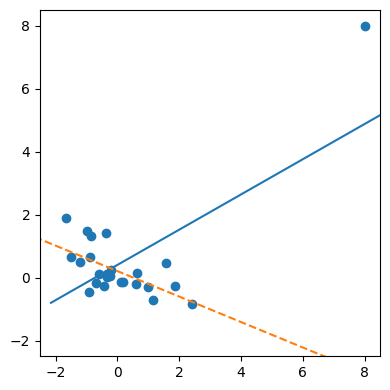

In [63]:
%matplotlib inline
from scipy.stats import linregress

np.random.seed(5)
x = np.random.normal(size=25)
y = -x / 5 + np.random.normal(size=25)
x[0] = 8
y[0] = 8

def abline(slope, intercept, ax):
    """Calculate coordinates of a line based on slope and intercept"""
    x_vals = np.array(ax.get_xlim())
    return (x_vals, intercept + slope * x_vals)

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(x, y)
slope, intercept, _, _, _ = linregress(x, y)
ax.plot(*abline(slope, intercept, ax))
slope, intercept, _, _, _ = linregress(x[1:], y[1:])
ax.plot(*abline(slope, intercept, ax), '--')
ax.set_xlim(-2.5, 8.5)
ax.set_ylim(-2.5, 8.5)

plt.tight_layout()
plt.show()

The package _statsmodel_ provides a number of plots to analyze the data point influence

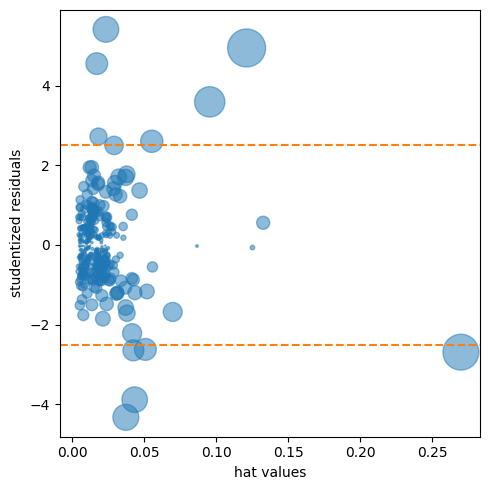

In [64]:
influence = OLSInfluence(result_98105)
fig, ax = plt.subplots(figsize=(5, 5))
ax.axhline(-2.5, linestyle='--', color='C1')
ax.axhline(2.5, linestyle='--', color='C1')
ax.scatter(influence.hat_matrix_diag, influence.resid_studentized_internal, 
           s=1000 * np.sqrt(influence.cooks_distance[0]),
           alpha=0.5)

ax.set_xlabel('hat values')
ax.set_ylabel('studentized residuals')

plt.tight_layout()
plt.show()

In [65]:
mask = [dist < .08 for dist in influence.cooks_distance[0]]
house_infl = house_98105.loc[mask]

ols_infl = sm.OLS(house_infl[outcome], house_infl[predictors].assign(const=1))
result_infl = ols_infl.fit()

pd.DataFrame({
    'Original': result_98105.params,
    'Influential removed': result_infl.params,
})

,Original,Influential removed
SqFtTotLiving,209.602346,230.052569
SqFtLot,38.933315,33.141600
Bathrooms,2282.264145,-16131.879785
Bedrooms,-26320.268796,-22887.865318
BldgGrade,130000.099737,114870.559737
const,-772549.862447,-647137.096716


### R
R visualizes leverage and Cook's distance, then refits after removing influential points.


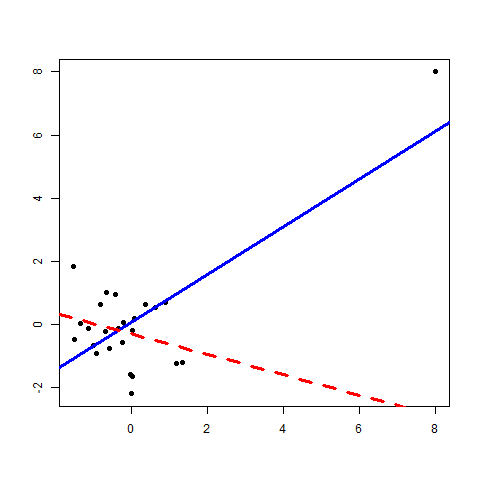

In [66]:
%%R
seed <- 11
set.seed(seed)
x <- rnorm(25)
y <- -x/5 + rnorm(25)
x[1] <- 8
y[1] <- 8

plot(x, y, xlab='', ylab='', pch=16)
model <- lm(y~x)
abline(a=model$coefficients[1], b=model$coefficients[2], col="blue", lwd=3)
model <- lm(y[-1]~x[-1])
abline(a=model$coefficients[1], b=model$coefficients[2], col="red", lwd=3, lty=2)

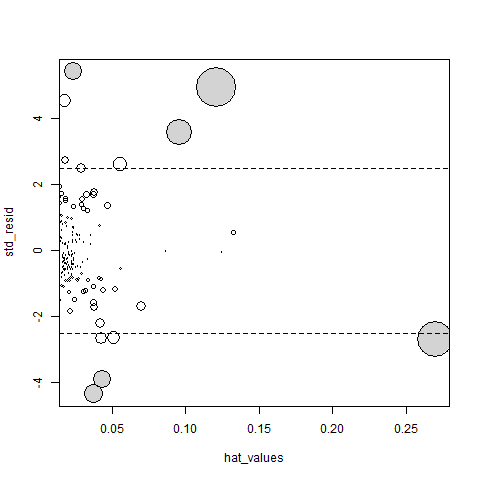

In [67]:
%%R
# influential observations
std_resid <- rstandard(lm_98105)
cooks_D <- cooks.distance(lm_98105)
hat_values <- hatvalues(lm_98105)
plot(subset(hat_values, cooks_D > 0.08), subset(std_resid, cooks_D > 0.08), 
     xlab='hat_values', ylab='std_resid',
     cex=10*sqrt(subset(cooks_D, cooks_D > 0.08)), pch=16, col='lightgrey')
points(hat_values, std_resid, cex=10*sqrt(cooks_D))
abline(h=c(-2.5, 2.5), lty=2)

In [68]:
%%R
lm_98105_inf <- lm(AdjSalePrice ~ SqFtTotLiving + SqFtLot + 
                     Bathrooms +  Bedrooms + BldgGrade,
                   subset=cooks_D<.08, data=house_98105)

### Summary: Influential values

| Operation | Python | R | Notes |
|---|---|---|---|
| Cook's distance | custom scatter/threshold checks | `cooks.distance()` plotting | Both flag influential observations. |
| Leverage | hat-value style diagnostics | `hatvalues()` | Equivalent leverage interpretation. |
| Refit after removal | model refit excluding points | model refit excluding points | Both test robustness of estimates. |

R provides dedicated influence helpers in base workflow, while Python often combines several diagnostics for the same decisions.


## Heteroskedasticity, Non-Normality and Correlated Errors

### Python
Python uses `seaborn.regplot()` and histogram diagnostics to inspect residual patterns and normality assumptions.


The `regplot` in _seaborn_ allows adding a lowess smoothing line to the scatterplot.

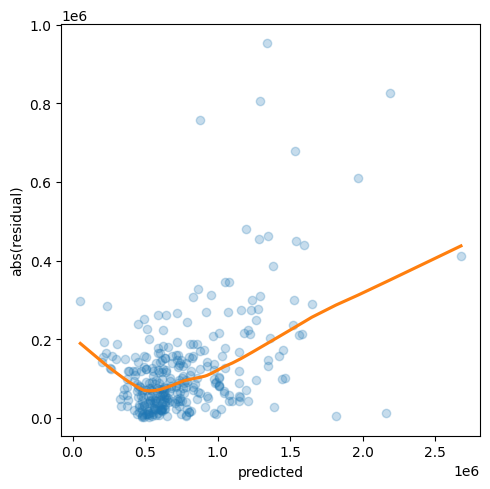

In [69]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.regplot(x=result_98105.fittedvalues, y=np.abs(result_98105.resid), 
            scatter_kws={'alpha': 0.25},
            line_kws={'color': 'C1'},
            lowess=True, ax=ax)
ax.set_xlabel('predicted')
ax.set_ylabel('abs(residual)')

plt.tight_layout()
plt.show()

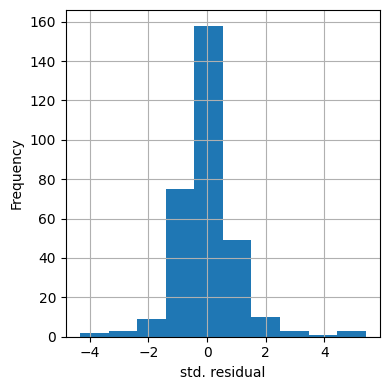

In [70]:
fig, ax = plt.subplots(figsize=(4, 4))
pd.Series(influence.resid_studentized_internal).hist(ax=ax)
ax.set_xlabel('std. residual')
ax.set_ylabel('Frequency')


plt.tight_layout()
plt.show()

### R
R uses `ggplot2` smoothers and histograms to inspect residual assumptions.


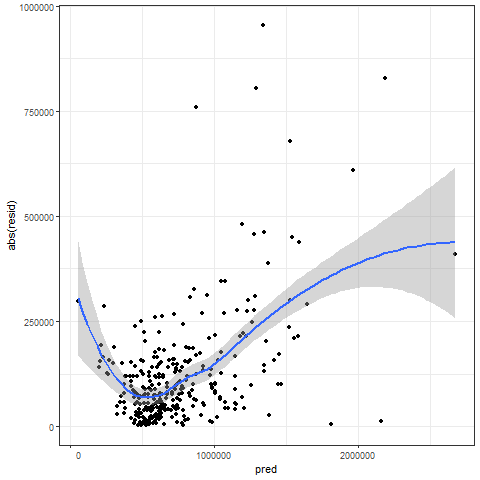

In [71]:
%%R
df <- data.frame(
  resid = residuals(lm_98105),
  pred = predict(lm_98105))

graph <- ggplot(df, aes(pred, abs(resid))) +
  geom_point() +
  geom_smooth(formula=y~x, method='loess') +
  scale_x_continuous(labels = function(x) format(x, scientific = FALSE)) +
  theme_bw()
graph

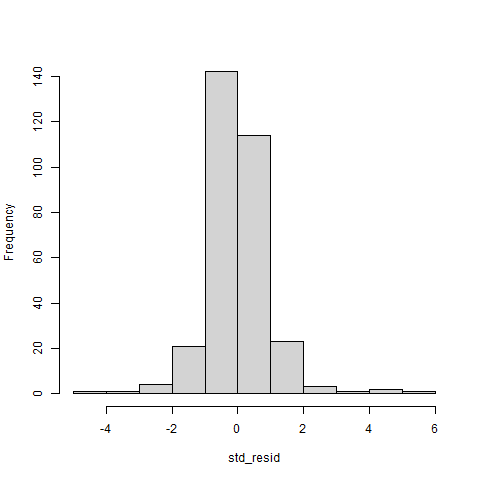

In [72]:
%%R
hist(std_resid, main='')

### Summary: Heteroskedasticity, Non-Normality and Correlated Errors

| Operation | Python | R | Notes |
|---|---|---|---|
| Variance pattern | lowess trend on residual plots | `geom_smooth(method='loess')` | Both visually assess heteroskedasticity. |
| Distribution check | residual histogram | residual histogram | Equivalent normality inspection. |
| Correlation hint | pattern-based residual review | pattern-based residual review | Both rely on visual diagnostics first. |

Python emphasizes explicit diagnostic layering, while R keeps assumption checks concise within ggplot pipelines.


## Partial Residual Plots and Nonlinearity

### Python

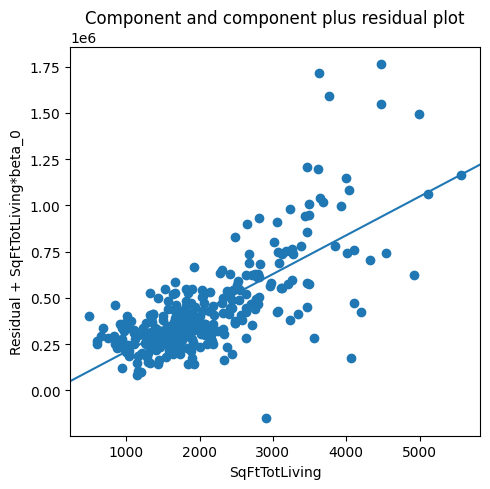

In [73]:
fig, ax = plt.subplots(figsize=(5, 5))
fig = sm.graphics.plot_ccpr(result_98105, 'SqFtTotLiving', ax=ax)

plt.tight_layout()
plt.show()

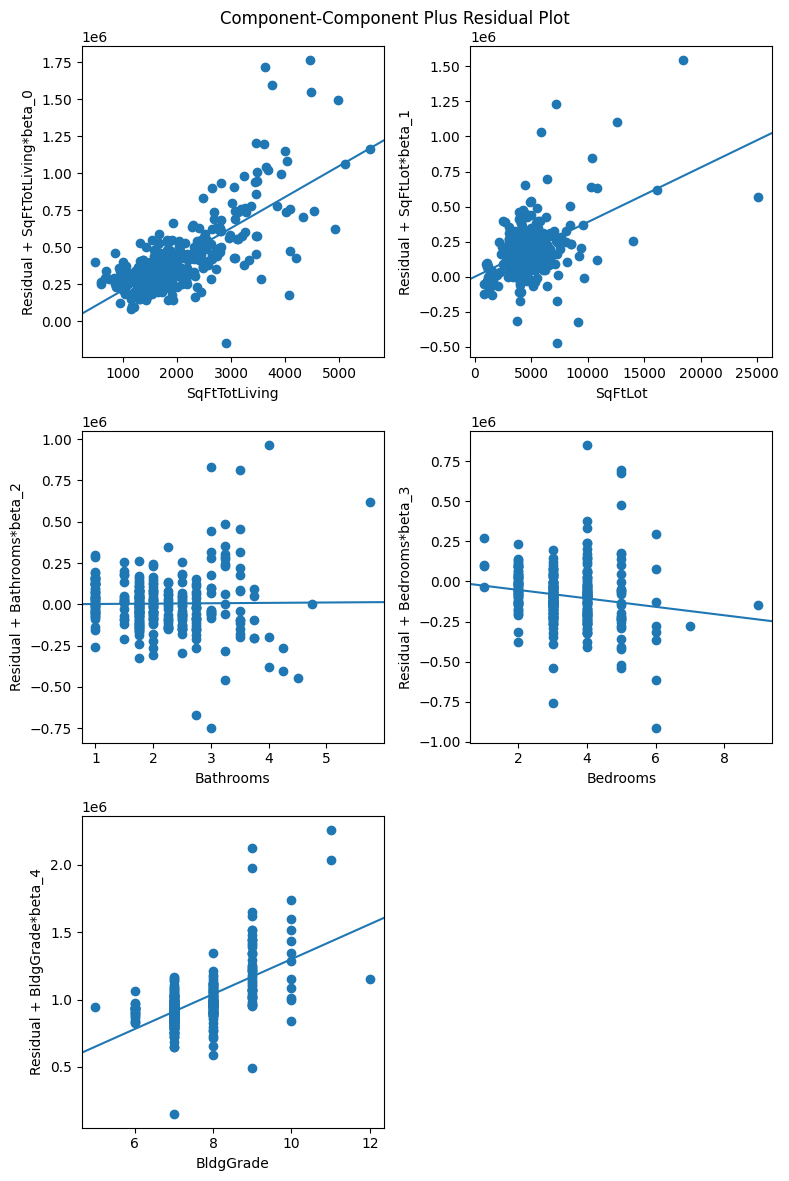

In [74]:
fig = plt.figure(figsize=(8, 12))
fig = sm.graphics.plot_ccpr_grid(result_98105, fig=fig)

### R
R derives partial residuals from `predict(..., type='terms')` and overlays loess trends.


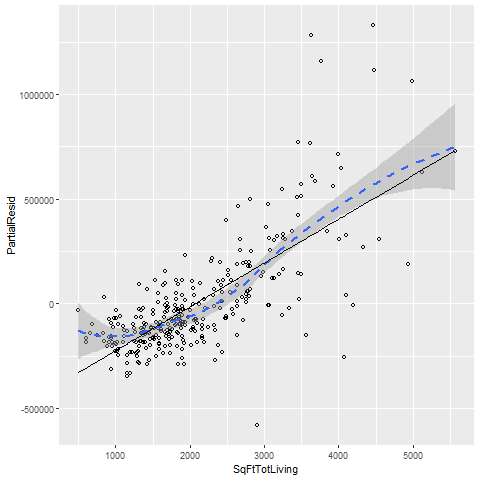

In [75]:
%%R
terms <- predict(lm_98105, type='terms')
partial_resid <- resid(lm_98105) + terms

df <- data.frame(SqFtTotLiving = house_98105[, 'SqFtTotLiving'],
                 Terms = terms[, 'SqFtTotLiving'],
                 PartialResid = partial_resid[, 'SqFtTotLiving'])
graph <- ggplot(df, aes(SqFtTotLiving, PartialResid)) +
  geom_point(shape=1) + scale_shape(solid = FALSE) +
  geom_smooth(linetype=2, formula=y~x, method='loess') + 
  geom_line(aes(SqFtTotLiving, Terms)) + 
  scale_y_continuous(labels = function(x) format(x, scientific = FALSE))
graph

### Summary: Partial Residual Plots and Nonlinearity

| Operation | Python | R | Notes |
|---|---|---|---|
| Partial residual computation | custom helper / model terms | `predict(..., type='terms')` | Both isolate marginal nonlinear behavior. |
| Nonlinearity overlay | lowess overlays | loess overlays | Equivalent visual objective. |
| Feature-wise inspection | panel plots | panel plots | Both compare variable-specific deviations from linearity. |

Both approaches diagnose nonlinearity effectively; Python tends to use custom helpers, R leans on compact term-based extraction.


## Polynomial and Spline Regression

### Python

In [76]:
model_poly = smf.ols(formula='AdjSalePrice ~  SqFtTotLiving + np.power(SqFtTotLiving, 2) + ' + 
                'SqFtLot + Bathrooms + Bedrooms + BldgGrade', data=house_98105)
result_poly = model_poly.fit()
print(result_poly.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     211.6
Date:                Wed, 15 Apr 2026   Prob (F-statistic):          9.95e-106
Time:                        17:36:32   Log-Likelihood:                -4217.9
No. Observations:                 313   AIC:                             8450.
Df Residuals:                     306   BIC:                             8476.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

The statsmodels implementation of a partial residual plot works only for linear term. Here is an implementation of a partial residual plot that, while inefficient, works for the polynomial regression.

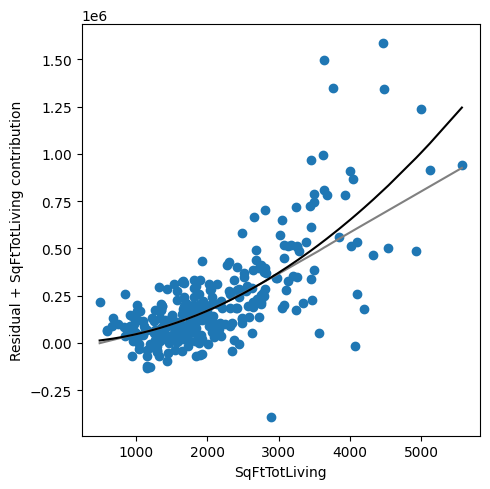

0.03879128168231146


In [77]:
def partialResidualPlot(model, df, outcome, feature, ax):
    y_pred = model.predict(df)
    # determine columns required for model
    required = set(model.params.index).intersection(df.columns)
    required.add(feature)
    copy_df = df[list(required)].copy().astype('float')
    for c in copy_df.columns:
        if c == feature:
            continue
        copy_df.loc[:, c] = 0.0
    feature_prediction = model.predict(copy_df)
    results = pd.DataFrame({
        'feature': df[feature],
        'residual': df[outcome] - y_pred,
        'ypartial': feature_prediction - model.params.iloc[0],
    })
    results = results.sort_values(by=['feature'])
    smoothed = sm.nonparametric.lowess(results.ypartial, results.feature, frac=1/3)
    
    ax.scatter(results.feature, results.ypartial + results.residual)
    ax.plot(smoothed[:, 0], smoothed[:, 1], color='gray')
    ax.plot(results.feature, results.ypartial, color='black')
    ax.set_xlabel(feature)
    ax.set_ylabel(f'Residual + {feature} contribution')
    return ax

fig, ax = plt.subplots(figsize=(5, 5))
partialResidualPlot(result_poly, house_98105, 'AdjSalePrice', 'SqFtTotLiving', ax)

plt.tight_layout()
plt.show()
print(result_poly.params.iloc[2])

### R
R fits polynomial terms with `poly()` and evaluates nonlinear patterns.


In [78]:
%%R
lm_poly <- lm(AdjSalePrice ~  poly(SqFtTotLiving, 2) + SqFtLot + 
                BldgGrade +  Bathrooms +  Bedrooms,
              data=house_98105)
terms <- predict(lm_poly, type='terms')
partial_resid <- resid(lm_poly) + terms
lm_poly


Call:
lm(formula = AdjSalePrice ~ poly(SqFtTotLiving, 2) + SqFtLot + 
    BldgGrade + Bathrooms + Bedrooms, data = house_98105)

Coefficients:
            (Intercept)  poly(SqFtTotLiving, 2)1  poly(SqFtTotLiving, 2)2  
             -402530.47               3271519.49                776934.02  
                SqFtLot                BldgGrade                Bathrooms  
                  32.56                135717.06                 -1435.12  
               Bedrooms  
               -9191.94  



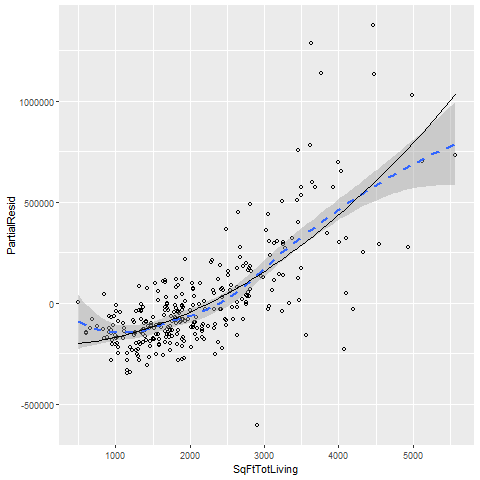

In [79]:
%%R
df <- data.frame(SqFtTotLiving = house_98105[, 'SqFtTotLiving'],
                 Terms = terms[, 1],
                 PartialResid = partial_resid[, 1])
graph <- ggplot(df, aes(SqFtTotLiving, PartialResid)) +
  geom_point(shape=1) + scale_shape(solid = FALSE) +
  geom_smooth(linetype=2, formula=y~x, method='loess') + 
  geom_line(aes(SqFtTotLiving, Terms)) +
  scale_y_continuous(labels = function(x) format(x, scientific = FALSE))
graph

### Summary: Polynomial and Spline Regression

| Operation | Python | R | Notes |
|---|---|---|---|
| Polynomial terms | explicit power terms | `poly(...)` | Same nonlinear regression intent. |
| Spline basis | `bs(...)` in model design | `bs(...)` in formula | Equivalent basis-expansion approach. |
| Model comparison | fit and inspect curves | fit and inspect curves | Both assess flexibility vs interpretability. |

R integrates polynomial/spline terms naturally in formulas, while Python usually composes features and models more explicitly.


## Splines

### Python

In [80]:
formula = ('AdjSalePrice ~ bs(SqFtTotLiving, df=6, degree=3) + ' + 
           'SqFtLot + Bathrooms + Bedrooms + BldgGrade')
model_spline = smf.ols(formula=formula, data=house_98105)
result_spline = model_spline.fit()
print(result_spline.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     131.8
Date:                Wed, 15 Apr 2026   Prob (F-statistic):          7.10e-104
Time:                        17:36:32   Log-Likelihood:                -4211.4
No. Observations:                 313   AIC:                             8445.
Df Residuals:                     302   BIC:                             8486.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


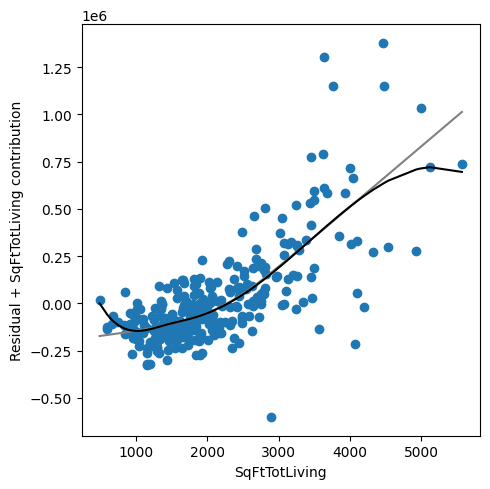

In [81]:
fig, ax = plt.subplots(figsize=(5, 5))
partialResidualPlot(result_spline, house_98105, 'AdjSalePrice', 'SqFtTotLiving', ax)

plt.tight_layout()
plt.show()

### R
R fits cubic B-splines with `bs(...)` and compares spline-term structure.


In [82]:
%%R
knots <- quantile(house_98105$SqFtTotLiving, p=c(.25, .5, .75))
lm_spline <- lm(AdjSalePrice ~ bs(SqFtTotLiving, knots=knots, degree=3) +  SqFtLot +  
                  Bathrooms + Bedrooms + BldgGrade,  data=house_98105)
lm_spline

terms1 <- predict(lm_spline, type='terms')
partial_resid1 <- resid(lm_spline) + terms1

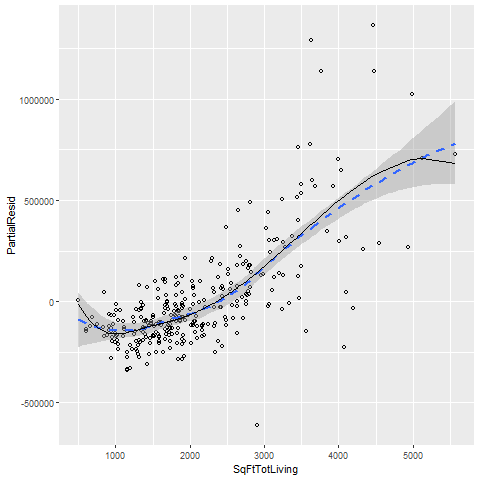

In [83]:
%%R
df1 <- data.frame(SqFtTotLiving = house_98105[, 'SqFtTotLiving'],
                 Terms = terms1[, 1],
                 PartialResid = partial_resid1[, 1])

graph <- ggplot(df1, aes(SqFtTotLiving, PartialResid)) +
  geom_point(shape=1) + scale_shape(solid = FALSE) +
  geom_smooth(linetype=2, formula=y~x, method='loess') + 
  geom_line(aes(SqFtTotLiving, Terms)) +
  scale_y_continuous(labels = function(x) format(x, scientific = FALSE))
graph

### Summary: Splines

| Operation | Python | R | Notes |
|---|---|---|---|
| Spline fitting | basis terms in model matrix | `bs(...)` formula term | Same cubic-spline concept. |
| Knot handling | explicit df/degree choices | explicit knots/degree | Both control smoothness through basis setup. |
| Partial effect view | custom partial plots | term-driven residual view | Equivalent interpretation of local curvature. |

Both ecosystems implement splines well; R is often terser in formulas, Python is often clearer about basis construction.


## Generalized Additive Models

### Python

#### Using statsmodels

In [84]:
from statsmodels.gam.api import GLMGam, BSplines

predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

x_spline = house_98105[predictors]
bs = BSplines(x_spline, df=[10] + [3] * 4, degree=[3] + [2] * 4)
# penalization weight
alpha = np.array([0] * 5)

formula = ('AdjSalePrice ~ SqFtTotLiving + ' + 
           'SqFtLot + Bathrooms + Bedrooms + BldgGrade')

gam_sm = GLMGam.from_formula(formula, data=house_98105, smoother=bs, alpha=alpha)
res_sm = gam_sm.fit()
print(res_sm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           AdjSalePrice   No. Observations:                  313
Model:                         GLMGam   Df Residuals:                   295.00
Model Family:                Gaussian   Df Model:                        17.00
Link Function:               Identity   Scale:                      2.7471e+10
Method:                         PIRLS   Log-Likelihood:                -4196.6
Date:                Wed, 15 Apr 2026   Deviance:                   8.1039e+12
Time:                        17:36:33   Pearson chi2:                 8.10e+12
No. Iterations:                     3   Pseudo R-squ. (CS):             0.9901
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept        -3.481e+05   1.18e+05  

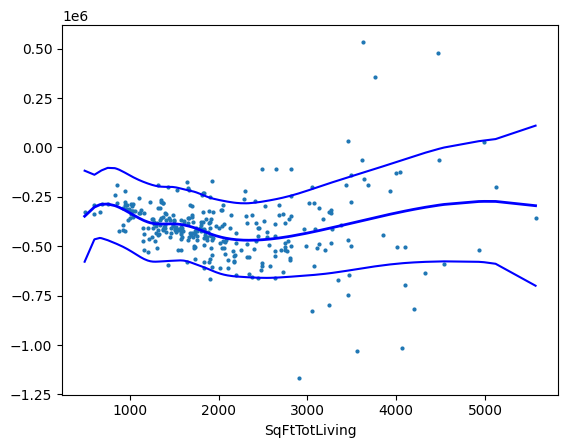

In [85]:
res_sm.plot_partial(0, cpr=True);

#### Using pyGAM

In [86]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
              'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'
X = house_98105[predictors].values
y = house_98105[outcome]

## model
gam = LinearGAM(s(0, n_splines=12) + l(1) + l(2) + l(3) + l(4))
gam.gridsearch(X, y)
print(gam.summary())

100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      7.6772
Link Function:                     IdentityLink Log Likelihood:                                 -7833.1159
Number of Samples:                          313 AIC:                                            15683.5863
                                                AICc:                                             15684.14
                                                GCV:                                      30838885095.1677
                                                Scale:                                    29480381715.8292
                                                Pseudo R-Squared:                                   0.8117
Feature Function                  Lam

C:\Users\micha\AppData\Local\Temp\ipykernel_5288\661170992.py:10: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


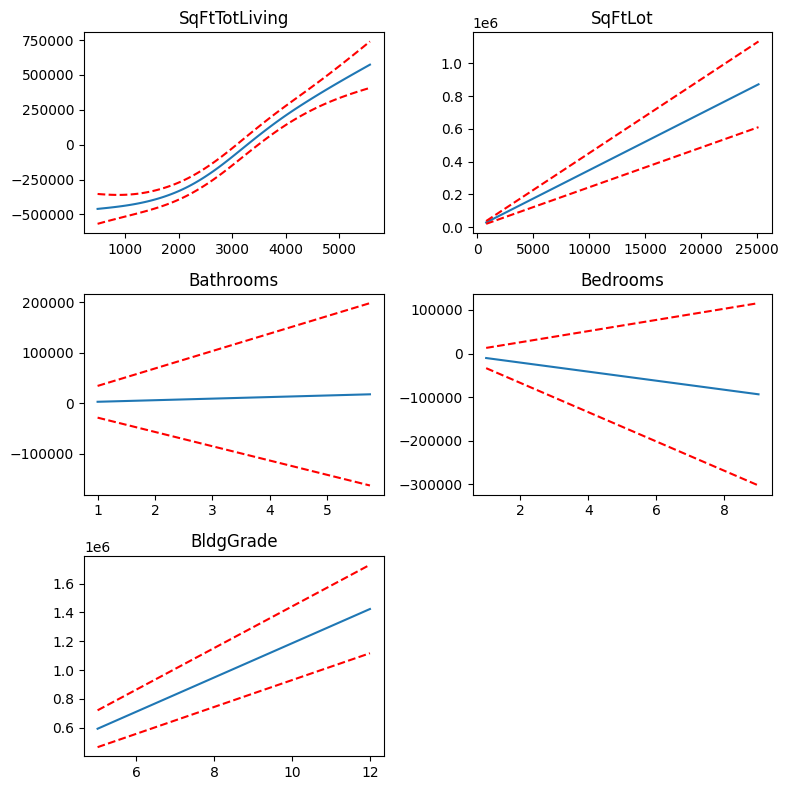

In [87]:
fig, axes = plt.subplots(figsize=(8, 8), ncols=2, nrows=3)

titles = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
for i, title in enumerate(titles):
    ax = axes[i // 2, i % 2]
    XX = gam.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX, width=.95)[1], c='r', ls='--')
    ax.set_title(titles[i]);
    
axes[2][1].set_visible(False)

plt.tight_layout()
plt.show()

### R
R fits `mgcv::gam()` and inspects smooth component behavior.


In [88]:
%%R
lm_gam <- gam(AdjSalePrice ~ s(SqFtTotLiving) + SqFtLot + 
              Bathrooms +  Bedrooms + BldgGrade, 
              data=house_98105)
terms <- predict.gam(lm_gam, type='terms')
partial_resid <- resid(lm_gam) + terms
lm_gam


Family: gaussian 
Link function: identity 

Formula:
AdjSalePrice ~ s(SqFtTotLiving) + SqFtLot + Bathrooms + Bedrooms + 
    BldgGrade

Estimated degrees of freedom:
4.49  total = 9.49 

GCV score: 30148051324     


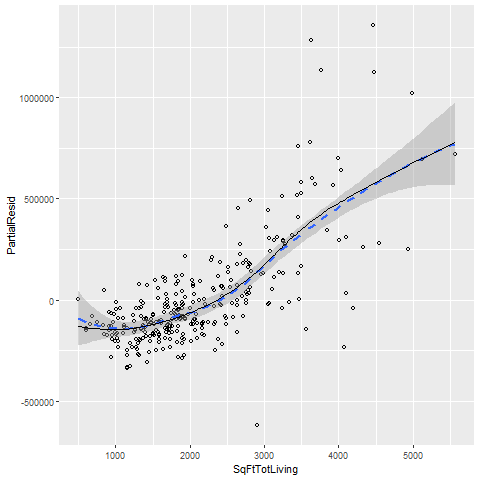

In [89]:
%%R
df <- data.frame(SqFtTotLiving = house_98105[, 'SqFtTotLiving'],
                 Terms = terms[, 5],
                 PartialResid = partial_resid[, 5])
graph <- ggplot(df, aes(SqFtTotLiving, PartialResid)) +
  geom_point(shape=1) + scale_shape(solid = FALSE) +
  geom_smooth(linetype=2, formula=y~x, method='loess') + 
  geom_line(aes(SqFtTotLiving, Terms)) +
  scale_y_continuous(labels = function(x) format(x, scientific = FALSE))
graph

### Summary: Generalized Additive Models

| Operation | Python | R | Notes |
|---|---|---|---|
| GAM fit | `GLMGam`, `pyGAM` | `mgcv::gam()` | Both fit additive smooth models. |
| Smooth term control | explicit smoother objects/params | smooth terms in formula | Same modeling idea with different APIs. |
| Partial effect plots | library-specific partial plots | term/residual visualizations | Both focus on nonlinear marginal effects. |

Python shows multi-library flexibility, while R provides a mature unified GAM workflow through `mgcv`.


# Additional material - not in book
# Regularization
## Lasso

### Python

In [90]:
from sklearn.linear_model import Lasso, LassoLars, LassoCV, LassoLarsCV
from sklearn.preprocessing import StandardScaler

In [91]:
subset = ['AdjSalePrice', 'SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
          'Bedrooms', 'BldgGrade']

house = pd.read_csv(HOUSE_CSV, sep='\t')
print(house[subset].head())

   AdjSalePrice  SqFtTotLiving  SqFtLot  Bathrooms  Bedrooms  BldgGrade
1      300805.0           2400     9373       3.00         6          7
2     1076162.0           3764    20156       3.75         4         10
3      761805.0           2060    26036       1.75         4          8
4      442065.0           3200     8618       3.75         5          7
5      297065.0           1720     8620       1.75         4          7


In [92]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade', 'PropertyType', 'NbrLivingUnits',
              'SqFtFinBasement', 'YrBuilt', 'YrRenovated', 
              'NewConstruction']
outcome = 'AdjSalePrice'

X = pd.get_dummies(house[predictors], drop_first=True)
X['NewConstruction'] = [1 if nc else 0 for nc in X['NewConstruction']]
columns = X.columns
# X = StandardScaler().fit_transform(X * 1.0)
y = house[outcome]

house_lm = LinearRegression()
print(house_lm.fit(X, y))

LinearRegression()


In [93]:
house_lasso = Lasso(alpha=10)
print(house_lasso.fit(X, y))

Lasso(alpha=10)


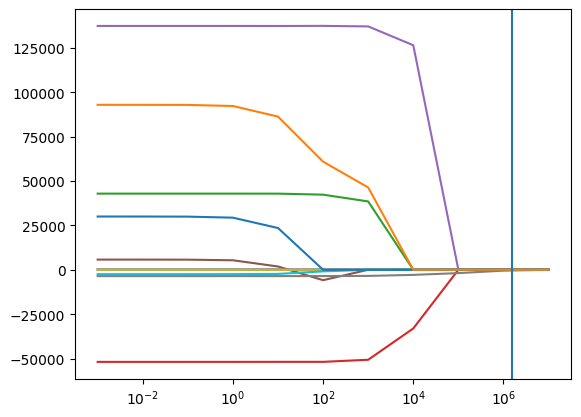

In [94]:
Method = LassoLars
MethodCV = LassoLarsCV
Method = Lasso
MethodCV = LassoCV

alpha_values = []
results = []
for alpha in [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000, 10000000]:
    model = Method(alpha=alpha)
    model.fit(X, y)
    alpha_values.append(alpha)
    results.append(model.coef_)
modelCV = MethodCV(cv=5)
modelCV.fit(X, y)
ax = pd.DataFrame(results, index=alpha_values, columns=columns).plot(logx=True, legend=False)
ax.axvline(modelCV.alpha_)
plt.show()

In [95]:
pd.DataFrame({
    'name': columns,
    'coef': modelCV.coef_, 
})

,name,coef
0,SqFtTotLiving,289.048846
1,SqFtLot,0.029471
2,Bathrooms,0.000000
3,Bedrooms,0.000000
4,BldgGrade,0.000000
5,NbrLivingUnits,0.000000
6,SqFtFinBasement,3.316479
7,YrBuilt,-0.000000
8,YrRenovated,45.727472
9,NewConstruction,0.000000


In [96]:
# Intercept: 6177658.144
# Coefficients:
#  SqFtTotLiving: 199.27474217544048
#  BldgGrade: 137181.13724627026
#  YrBuilt: -3564.934870415041
#  Bedrooms: -51974.76845567939
#  Bathrooms: 42403.059999677665
#  PropertyType_Townhouse: 84378.9333363999
#  SqFtFinBasement: 7.032178917565108
#  PropertyType_Single Family: 22854.87954019308